In [ ]:
import pandas as pd
import numpy as np

# Dataset
data = pd.DataFrame({
    "customer_name": ["Harsha", "Riya", "Enola", "Esha", "Ram"],
    "Internet_Speed": [10, 4, 20, 50, 2],
    "Payment_failure": [3, 4, 2, 0, 0],
    "Delivery_charges": [2000, 5000, 400, 250, 1500],
    "Purchase_completed": [0, 0, 1, 1, 0]
})

print(data)


# Total completed and abandoned
print("\nPurchase Status Count:")
print(data['Purchase_completed'].value_counts())

# Diagnosis conditions
data['Poor_Internet'] = data['Internet_Speed'] < 10
data['Payment_Issue'] = data['Payment_failure'] > 0
data['High_Delivery_Charge'] = data['Delivery_charges'] > 1500

print("\nDiagnosis Table:")
print(data[['customer_name',
            'Poor_Internet',
            'Payment_Issue',
            'High_Delivery_Charge',
            'Purchase_completed']])

# Root cause analysis for abandoned purchases
abandoned = data[data['Purchase_completed'] == 0]

print("\nRoot Cause Analysis:")

print("Customers with poor internet:",
      abandoned['Poor_Internet'].sum())

print("Customers with payment issues:",
      abandoned['Payment_Issue'].sum())

print("Customers with high delivery charges:",
      abandoned['High_Delivery_Charge'].sum())

  customer_name  Internet_Speed  Payment_failure  Delivery_charges  \
0        Harsha              10                3              2000   
1          Riya               4                4              5000   
2         Enola              20                2               400   
3          Esha              50                0               250   
4           Ram               2                0              1500   

   Purchase_completed  
0                   0  
1                   0  
2                   1  
3                   1  
4                   0  

Purchase Status Count:
Purchase_completed
0    3
1    2
Name: count, dtype: int64

Diagnosis Table:
  customer_name  Poor_Internet  Payment_Issue  High_Delivery_Charge  \
0        Harsha          False           True                  True   
1          Riya           True           True                  True   
2         Enola          False           True                 False   
3          Esha          False          False     

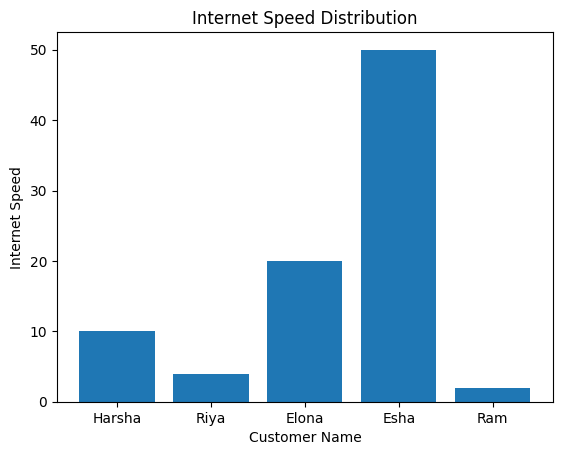

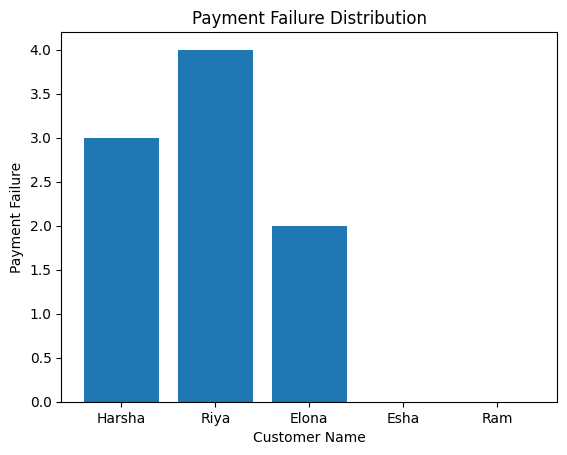

In [ ]:
import matplotlib.pyplot as plt
#barplot(Internet speed distribution)
plt.bar(data['customer_name'], data['Internet_Speed'])
plt.xlabel('Customer Name')
plt.ylabel('Internet Speed')
plt.title('Internet Speed Distribution')
plt.show()

plt.bar(data['customer_name'], data['Payment_failure'],)
plt.xlabel('Customer Name')
plt.ylabel('Payment Failure')
plt.title('Payment Failure Distribution')
plt.show()

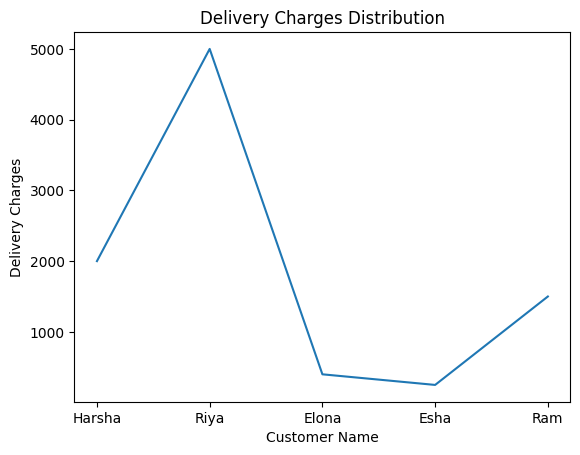

In [ ]:
plt.plot(data['customer_name'], data['Delivery_charges'])
plt.xlabel('Customer Name')
plt.ylabel('Delivery Charges')
plt.title('Delivery Charges Distribution')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data=pd.read_csv("/content/ecommerce_sales_34500.csv")
data

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,2025-08-13,3,North,No,8.35,3.04,-0.12,23,Female
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,2023-12-04,6,South,Yes,21.56,3.37,6.33,61,Female
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,2025-02-01,6,East,No,1618.20,12.18,182.00,41,Female
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,2024-03-27,6,East,No,21.94,5.61,0.53,27,Female


In [ ]:
data.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [ ]:

data['High_Price'] = data['price'] > 5000

data['High_Discount'] = data['discount'] > 30

data['Late_Delivery'] = data['delivery_time_days'] > 7

data['High_Shipping_Cost'] = data['shipping_cost'] > 500

data['Returned_Product'] = data['returned'] == 'Yes'

data['Low_Profit'] = data['profit_margin'] < 10


print("\nDiagnosis Table:\n")

print(data[[
    'order_id',
    'category',
    'price',
    'discount',
    'delivery_time_days',
    'shipping_cost',
    'profit_margin',
    'returned',
    'High_Price',
    'High_Discount',
    'Late_Delivery',
    'High_Shipping_Cost',
    'Low_Profit'
]])

returned_orders = data[data['returned'] == 'Yes']
print("\nROOT CAUSE ANALYSIS\n")
print("Returned orders count:",len(returned_orders))
print(f"\nProducts with high price:{returned_orders['High_Price'].sum()}")
print(f"\nProducts with heavy discount:{returned_orders['High_Discount'].sum()}")
print(f"\nProducts with late delivery:{returned_orders['Late_Delivery'].sum()}")
print(f"\nProducts with high shipping cost:{returned_orders['High_Shipping_Cost'].sum()}")
print(f"\nProducts with low profit:{returned_orders['Low_Profit'].sum()}")



Diagnosis Table:

      order_id     category   price  discount  delivery_time_days  \
0      O100000         Home  164.08      0.15                   4   
1      O100001      Grocery   24.73      0.00                   6   
2      O100002  Electronics  175.58      0.05                   4   
3      O100003  Electronics   63.67      0.00                   6   
4      O100004         Home   16.33      0.15                   6   
...        ...          ...     ...       ...                 ...   
34495  O134495      Fashion   10.44      0.20                   3   
34496  O134496       Beauty    4.79      0.10                   6   
34497  O134497  Electronics  323.64      0.00                   6   
34498  O134498         Home   23.09      0.05                   6   
34499  O134499         Home   76.84      0.00                   6   

       shipping_cost  profit_margin returned  High_Price  High_Discount  \
0               7.88          31.17       No       False          False   
1 

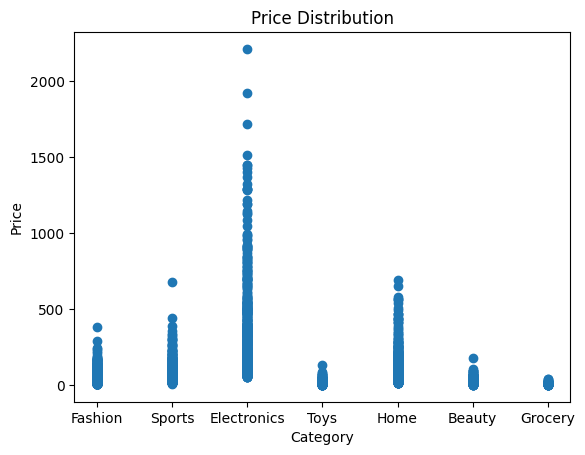

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(returned_orders['category'], returned_orders['price'])
plt.xlabel('Category')
plt.ylabel('Price')
plt.title('Price Distribution')
plt.show()


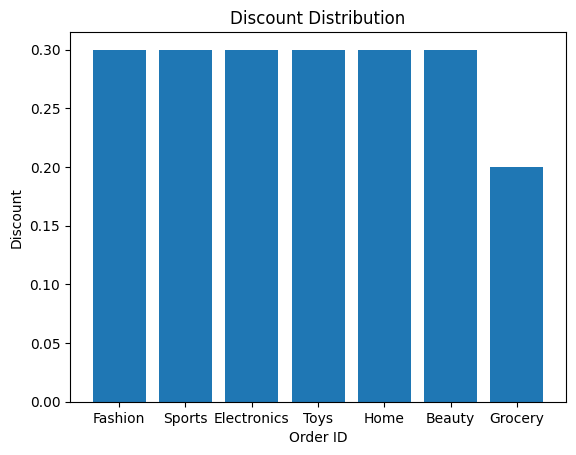

In [ ]:
plt.bar(returned_orders['category'], returned_orders['discount'])
plt.xlabel('Order ID')
plt.ylabel('Discount')
plt.title('Discount Distribution')
plt.show()


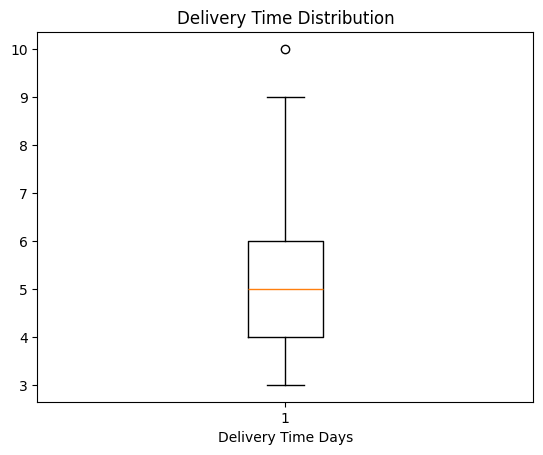

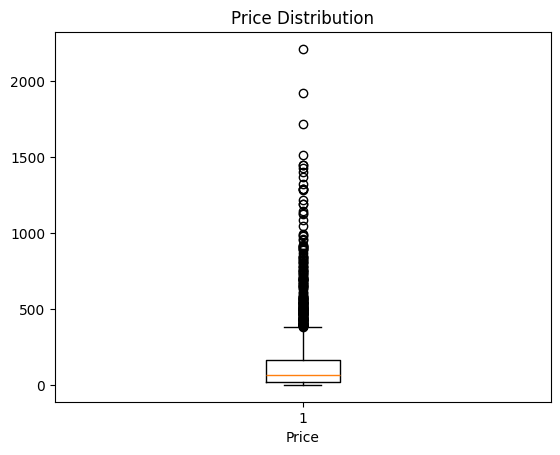

In [ ]:
plt.boxplot(returned_orders['delivery_time_days'])
plt.xlabel('Delivery Time Days')
plt.title('Delivery Time Distribution')
plt.show()


plt.boxplot(returned_orders['price'])
plt.xlabel('Price')
plt.title('Price Distribution')
plt.show()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data=pd.DataFrame(
    {
     "Water_consumption":[10,5,7,10,3,8,2],
     "Days":[1,2,3,4,5,6,7]
     }
)
print(data)
avg=data['Water_consumption'].mean()
print(f"Average water consumption:{avg}")
print(f"Total water usage :{data['Water_consumption'].sum()}")
usage_increased=[]
for i in data['Water_consumption']:
  if i>avg:
    usage_increased.append((i-avg))
  else:
    usage_increased.append(0)
data['Usage_increased']=usage_increased
avg_usage=data['Usage_increased'].mean()
print(f"Average usage increase:{avg_usage}")
print(data)
tank_capacity=45
water=0
for i in data['Water_consumption']:
  water+=i
  if water<tank_capacity:
    tank_capacity-water
  else:
    print("Water shortage")

   Water_consumption  Days
0                 10     1
1                  5     2
2                  7     3
3                 10     4
4                  3     5
5                  8     6
6                  2     7
Average water consumption:6.428571428571429
Total water usage :45
Average usage increase:1.3265306122448979
   Water_consumption  Days  Usage_increased
0                 10     1         3.571429
1                  5     2         0.000000
2                  7     3         0.571429
3                 10     4         3.571429
4                  3     5         0.000000
5                  8     6         1.571429
6                  2     7         0.000000
Water shortage


Initial Data:
   Water_consumption  Days
0                200     1
1                190     2
2                211     3
3                212     4
4                213     5

Average water consumption: 205.20 liters

Daily Change:
   Water_consumption  Days  Difference
0                200     1         NaN
1                190     2       -10.0
2                211     3        21.0
3                212     4         1.0
4                213     5         1.0

Average daily increase in water consumption: 3.25 liters

Water shortage starts on Day 3
Shortage amount on that day: 6 liters


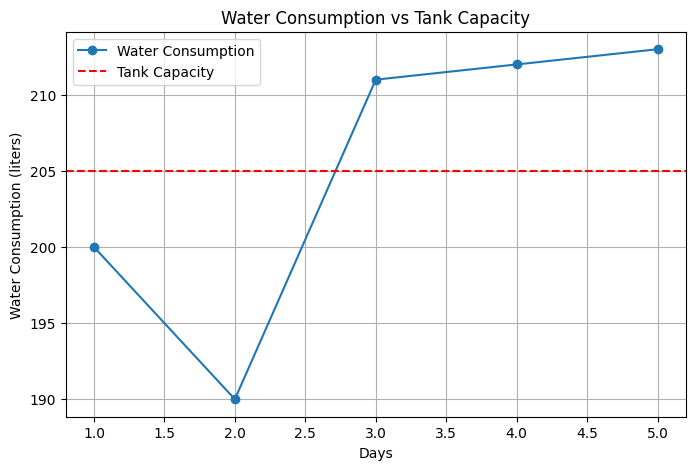

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.DataFrame(
    {
        "Water_consumption": [200, 190, 211, 212, 213],
        "Days": [1, 2, 3, 4, 5]
    }
)

print("Initial Data:")
print(data)

avg = data['Water_consumption'].mean()
print(f"\nAverage water consumption: {avg:.2f} liters")

data['Difference'] = data['Water_consumption'].diff()

print("\nDaily Change:")
print(data)

avg_increase = data['Difference'].mean()
print(f"\nAverage daily increase in water consumption: {avg_increase:.2f} liters")

tank_capacity = 205

data['Shortage'] = data['Water_consumption'] > tank_capacity

shortage_days = data[data['Shortage']]

if not shortage_days.empty:
    first_shortage_day = shortage_days.iloc[0]['Days']
    shortage_amount = shortage_days.iloc[0]['Water_consumption'] - tank_capacity

    print(f"\nWater shortage starts on Day {int(first_shortage_day)}")
    print(f"Shortage amount on that day: {shortage_amount} liters")
else:
    print("\nNo water shortage detected.")

plt.figure(figsize=(8,5))
plt.plot(data['Days'], data['Water_consumption'],
         marker='o', label='Water Consumption')
plt.axhline(y=tank_capacity, color='r',
            linestyle='--', label='Tank Capacity')
plt.xlabel("Days")
plt.ylabel("Water Consumption (liters)")
plt.title("Water Consumption vs Tank Capacity")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/weather_forecast_data.csv')
df.head()


,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [15]:
df.describe()


,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


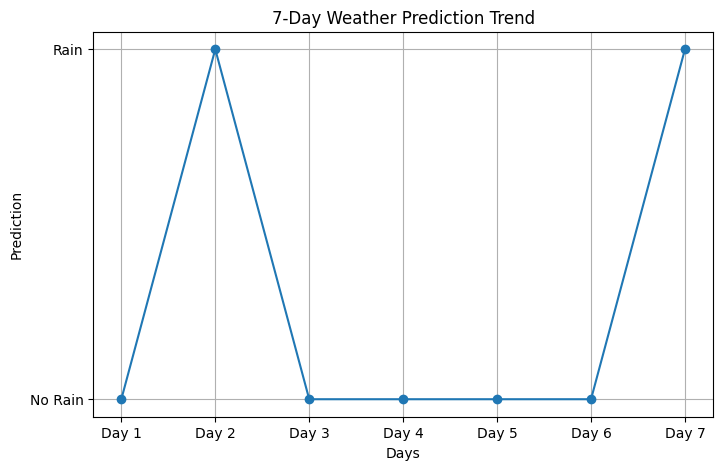

In [17]:
avg_humidity = df['Humidity'].mean()
avg_cloud = df['Cloud_Cover'].mean()

days = []
predictions = []

for i, row in enumerate(df.tail(7).itertuples(), start=1):
    humidity = row.Humidity
    cloud_cover = row.Cloud_Cover
    if humidity > avg_humidity and cloud_cover > avg_cloud:
        pred = "Rain"
        value = 1
    else:
        pred = "No Rain"
        value = 0

    days.append(f"Day {i}")
    predictions.append(value)

plt.figure(figsize=(8,5))
plt.plot(days, predictions, marker='o')

plt.title("7-Day Weather Prediction Trend")
plt.xlabel("Days")
plt.ylabel("Prediction")
plt.yticks([0,1], ["No Rain", "Rain"])
plt.grid(True)
plt.show()

In [20]:
tomorrow = df.iloc[-1]

if tomorrow['Humidity'] > avg_humidity and tomorrow['Cloud_Cover'] > avg_cloud:
    print("Tomorrow's Weather: Rain")
else:
    print("Tomorrow's Weather: No Rain")

Tomorrow's Weather: Rain


In [48]:
# Prescriptive Analysis - Bed Allocation

import pandas as pd
import numpy as np
data = pd.DataFrame(
    {
    "Patient Name": ["Kumar", "Reddy", "Arjun", "Meena", "Kiran"],
    "Age": [68, 45, 32, 72, 51],
    "Condition": ["Critical", "Serious", "Stable", "Critical", "Serious"],
    "Oxygen Level": [78, 85, 95, 74, 88]
}
)
data

,Patient Name,Age,Condition,Oxygen Level
0,Kumar,68,Critical,78
1,Reddy,45,Serious,85
2,Arjun,32,Stable,95
3,Meena,72,Critical,74
4,Kiran,51,Serious,88


In [47]:
total_beds = 3
def calculate_priority(row):
    if row["Condition"] == "Critical":
        condition_weight = 50
    elif row["Condition"] == "Serious":
        condition_weight = 30
    else:
        condition_weight = 10
    if row["Age"] > 60:
        age_factor = 20
    elif row["Age"] >= 40:
        age_factor = 10
    else:
        age_factor = 5
    score = (100 - row["Oxygen Level"]) + condition_weight + age_factor
    return score
data["Priority Score"] = data.apply(calculate_priority, axis=1)
data = data.sort_values(by="Priority Score", ascending=False)
data["Bed Status"] = "No Bed Available"
data.iloc[:total_beds, data.columns.get_loc("Bed Status")] = "Bed Allocated"
def prescription(row):
    if row["Condition"] == "Critical":
        return "Assign Ventilator"
    elif row["Condition"] == "Serious":
        return "Provide Oxygen"
    else:
        return "Tablets"
data["Prescription"] = data.apply(prescription, axis=1)
print("\nFinal Hospital Allocation Report:\n")
print(data)
no_bed_patients = data[data["Bed Status"] == "No Bed Available"]
print("\nPatients Without Beds:\n")
if len(no_bed_patients) > 0:
    print(no_bed_patients[["Patient Name","Condition","Priority Score"]])
else:
    print("All patients received beds.")


Final Hospital Allocation Report:

  Patient Name  Age Condition  Oxygen Level  Priority Score        Bed Status  \
3        Meena   72  Critical            74              96     Bed Allocated   
0        Kumar   68  Critical            78              92     Bed Allocated   
1        Reddy   45   Serious            85              55     Bed Allocated   
4        Kiran   51   Serious            88              52  No Bed Available   
2        Arjun   32    Stable            95              20  No Bed Available   

        Prescription  
3  Assign Ventilator  
0  Assign Ventilator  
1     Provide Oxygen  
4     Provide Oxygen  
2            Tablets  

Patients Without Beds:

  Patient Name Condition  Priority Score
4        Kiran   Serious              52
2        Arjun    Stable              20


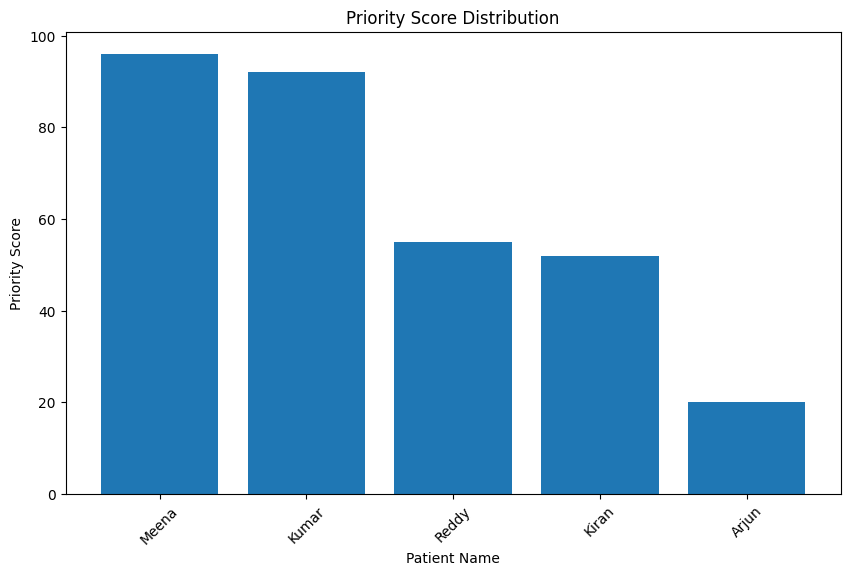

In [43]:
plt.figure(figsize=(10,6))
plt.bar(data["Patient Name"], data["Priority Score"])
plt.xlabel("Patient Name")
plt.ylabel("Priority Score")
plt.title("Priority Score Distribution")
plt.xticks(rotation=45)
plt.show()


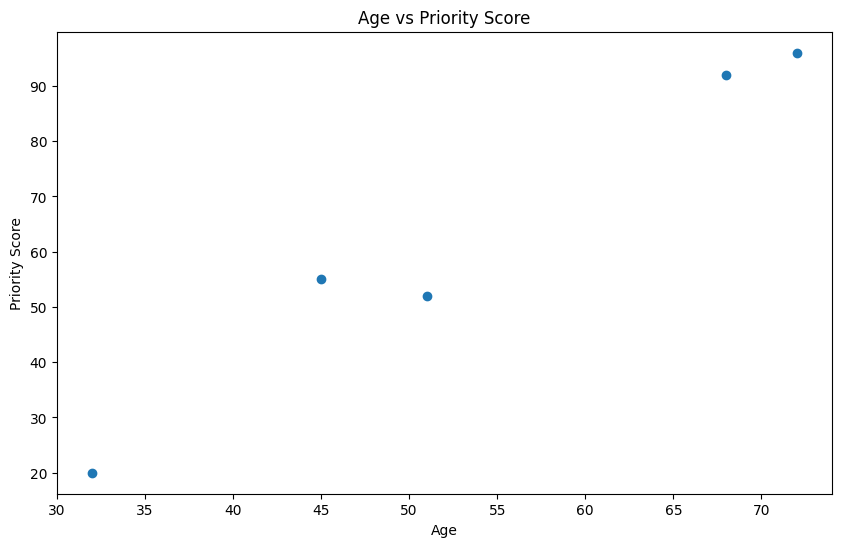

In [44]:
plt.figure(figsize=(10,6))
plt.scatter(data["Age"], data["Priority Score"])
plt.xlabel("Age")
plt.ylabel("Priority Score")
plt.title("Age vs Priority Score")
plt.show()


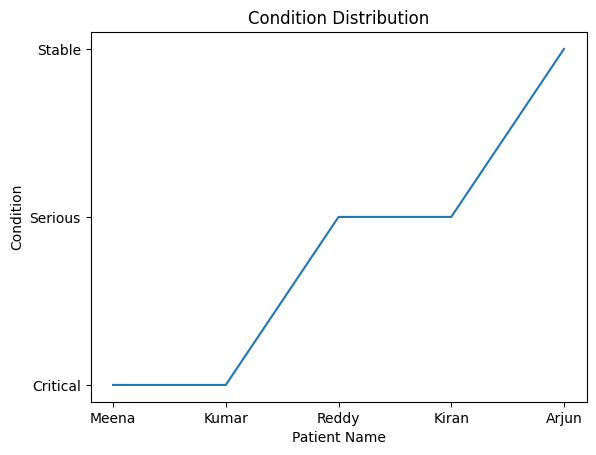

In [46]:
plt.plot(data['Patient Name'],data['Condition'])
plt.xlabel('Patient Name')
plt.ylabel('Condition')
plt.title('Condition Distribution')
plt.show()